In [1]:
import sys
import os
sys.path.append(os.getcwd())

os.makedirs("data", exist_ok=True)

from utils.data_loader import load_wine_data
from models.wine_dataset import WineDataset
from models.wine_sample import WineSample

In [2]:
import pandas as pd
import numpy as np
import statistics
from sklearn.neighbors import KNeighborsClassifier
from models.wine_sample import WineSample
from models import wine_sample
from utils import data_loader
from utils.visualization import plot_feature_distribution, plot_scatter

In [3]:
df = load_wine_data("data/wine.csv")

dataset = WineDataset()
dataset.load_data(df)

print(f"Dataset loaded with {len(dataset)} samples.")

Dataset loaded with 178 samples.


In [4]:
dataset.train_model()
print("Model trained successfully.")

Model trained successfully.


In [5]:
stats = dataset.get_summary_stats()

for key, value in stats.items():
    print(f"{key}: {value:.3f}")

alcohol: 13.001
malic_acid: 2.336
ash: 2.367
alcalinity_of_ash: 19.495
magnesium: 99.742
total_phenols: 2.295
flavanoids: 2.029
nonflavanoid_phenols: 0.362
proanthocyanins: 1.591
color_intensity: 5.058
hue: 0.957
od280/od315_of_diluted_wines: 2.612
proline: 746.893


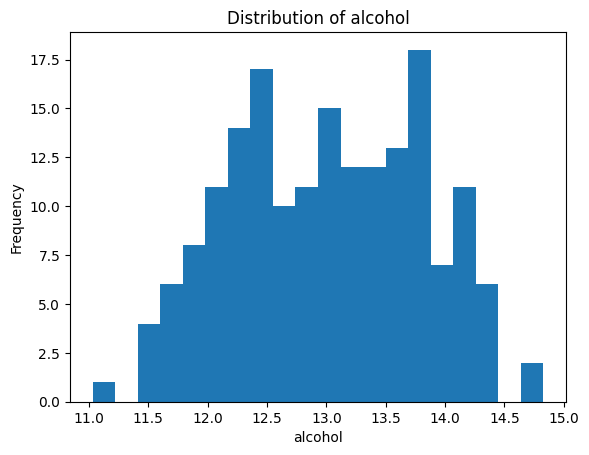

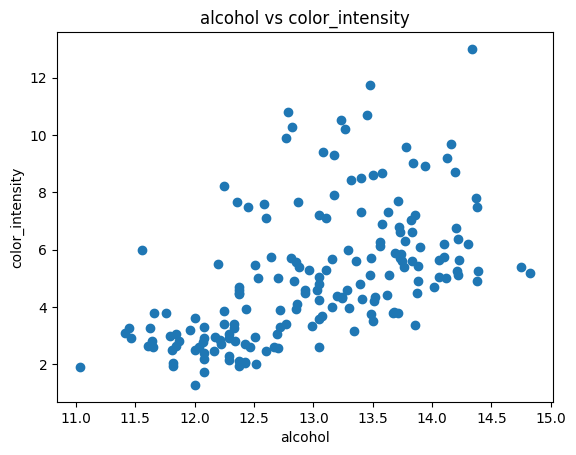

In [6]:
plot_feature_distribution(dataset.df, "alcohol")
plot_scatter(dataset.df, "alcohol", "color_intensity")

In [7]:
print("Class Distribution:")
print(dataset.get_class_distribution())

Class Distribution:
{np.float64(0.0): 59, np.float64(1.0): 71, np.float64(2.0): 48}


In [8]:
while True:
    try:
        print("\nEnter wine features (or type 'q' to quit):")

        alcohol = input("Alcohol: ")
        if alcohol.lower() == 'q':
            break

        malic = input("Malic Acid: ")
        color = input("Color Intensity: ")
        hue = input("Hue: ")

        features = {
            "alcohol": float(alcohol),
            "malic_acid": float(malic),
            "ash": float(input("Ash: ")),
            "alcalinity_of_ash": float(input("Alcalinity of Ash: ")),
            "magnesium": float(input("Magnesium: ")),
            "total_phenols": float(input("Total Phenols: ")),
            "flavanoids": float(input("Flavanoids: ")),
            "nonflavanoid_phenols": float(input("Nonflavanoid Phenols: ")),
            "proanthocyanins": float(input("Proanthocyanins: ")),
            "color_intensity": float(color),
            "hue": float(hue),
            "od280/od315_of_diluted_wines": float(input("OD280/OD315: ")),
            "proline": float(input("Proline: "))
}
        sample = WineSample(features)
        prediction = dataset.predict(sample)

        print(f"Predicted Wine Class: {prediction}")

    except ValueError:
        print("Invalid input! Please enter numeric values.")
    except Exception as e:
        print(f"Error: {e}")


Enter wine features (or type 'q' to quit):


Alcohol:  14.23
Malic Acid:  1.71
Color Intensity:  2.43
Hue:  5.64
Ash:  2.43
Alcalinity of Ash:  15.6
Magnesium:  127.0
Total Phenols:  2.8
Flavanoids:  3.06
Nonflavanoid Phenols:  .28
Proanthocyanins:  2.29
OD280/OD315:  3.92
Proline:  1065


Predicted Wine Class: 0

Enter wine features (or type 'q' to quit):


C:\Users\arltt\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


Alcohol:  q


In [ ]:
print("Average Alcohol:", dataset.get_average_alcohol())
print("Statistics (Alcohol):", dataset.describe_with_statistics_module())
print("Feature Pairs:", dataset.pair_features_with_names()[:5])